# Ensemble Feature Combination Analysis

This notebook analyzes the performance of different feature combinations for EEG classification using ensemble methods. It loads prediction results, computes various metrics (accuracy, balanced accuracy, F1, AUC, AUPRC, etc.), and visualizes the best combinations based on these metrics.

Key steps:
- Load prediction files for all feature combinations
- Compute and aggregate performance metrics
- Identify the best combinations for each combination length
- Visualize ROC curves for the best combinations

In [1]:
# Imports and Setup
import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, precision_recall_curve, roc_curve, confusion_matrix,
    balanced_accuracy_score, average_precision_score, auc as sk_auc
    )


# Available data paths
available_paths = [
    '/space/gzanardini/tuh/tuh_ensemble_bucket/', 
    '/space/gzanardini/tuh/tuh_ensemble_logits/',
    '/space/gzanardini/emc/emc_ensemble_bucket/',
    '/space/gzanardini/emc/emc_ensemble_logits/'
]

print("Available data paths:")
for i, path in enumerate(available_paths):
    print(f"{i+1}. {path}")

Available data paths:
1. /space/gzanardini/tuh/tuh_ensemble_bucket/
2. /space/gzanardini/tuh/tuh_ensemble_logits/
3. /space/gzanardini/emc/emc_ensemble_bucket/
4. /space/gzanardini/emc/emc_ensemble_logits/


In [2]:
# Utility Functions for ROC and Display
pd.options.display.max_columns = 999
pd.options.display.max_rows = None
np.set_printoptions(threshold=np.inf)

plt.style.use('ggplot')

def interpolate(p1_fpr, p1_tpr, p2_fpr, p2_tpr, x):
    """Linear interpolation of TPR at FPR = x between two points."""
    slope = (p2_tpr - p1_tpr) / (p2_fpr - p1_fpr)
    return p1_tpr + slope * (x - p1_fpr)

def tpr_for_fpr(fprsample, fpr_arr, tpr_arr):
    """Find/interpolate TPR at a specific FPR. Assumes fpr_arr is sorted ascending."""
    i = np.searchsorted(fpr_arr, fprsample, side="right") - 1
    if i < 0:  # fprsample < smallest FPR in curve
        return tpr_arr[0]
    if fpr_arr[i] == fprsample or i == len(fpr_arr) - 1:
        return tpr_arr[i]
    return interpolate(fpr_arr[i], tpr_arr[i], fpr_arr[i + 1], tpr_arr[i + 1], fprsample)

def vertical_avg_roc(roc_data):
    """Average ROC curve vertically across multiple ROC curves."""
    fprs = []
    tprs = []
    for fpr, tpr, _ in roc_data:
        fprs.append(fpr)
        tprs.append(tpr)
    fprs = np.concatenate(fprs)

    # make sure fprs ends with 1 and starts with 0
    if fprs[0] != 0:
        fprs = np.insert(fprs, 0, 0)
    if fprs[-1] != 1:
        fprs = np.append(fprs, 1)

    fprs = np.sort(np.unique(fprs))
    tprs = np.zeros(shape=(len(roc_data), len(fprs)))

    for i, fpr in enumerate(fprs):
        for curve_idx, (fpr_arr, tpr_arr, _) in enumerate(roc_data):
            tprs[curve_idx, i] = tpr_for_fpr(fpr, fpr_arr, tpr_arr)
    tpr = np.mean(tprs, axis=0)
    return fprs, tpr

def calculate_bac(labels, scores, sens_thresh):
    """
    Calculate balanced accuracy with a sensitivity threshold.
    Returns: (bac, fpr, tpr, thresholds)
    """
    fpr, tpr, thresholds = roc_curve(labels, scores)
    threshold_sensitivity = thresholds[np.where(tpr >= sens_thresh)[0][0]]
    adjusted_predictions = (scores >= threshold_sensitivity).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, adjusted_predictions).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    bac = ((sensitivity + specificity) / 2)
    return bac, fpr, tpr, thresholds

In [3]:
def analyze_ensemble_performance(datafolder, save_plots=True, plot_prefix="ensemble"):
    """
    Analyze ensemble performance for all feature combinations from prediction files.
    
    Parameters:
    -----------
    datafolder : str
        Path to the folder containing prediction CSV files
    save_plots : bool
        Whether to save plots to files
    plot_prefix : str
        Prefix for saved plot filenames
        
    Returns:
    --------
    tuple : (df_summary, df_best, std_df)
        Summary dataframe, best combinations dataframe, and standard deviation dataframe
    """
    import warnings
    warnings.filterwarnings("ignore", category=FutureWarning)
    
    print(f"Analyzing data from: {datafolder}")
    
    # List all prediction files
    files = [file for file in os.listdir(datafolder) if file.endswith('.csv')]
    print(f"Found {len(files)} prediction files.")
    
    if len(files) == 0:
        print("No prediction files found!")
        return None, None, None
    
    # Generate All Feature Combinations and Compute Metrics
    feature_names = ['cc', 'cwt', 'dwt', 'plv', 'mst', 'sst', 'spectral', 'utm', 'gcc', 'gplv']
    combinations = []  # All combinations of 2 to len(feature_names) features
    comb_names = []
    for i in range(2, len(feature_names) + 1):
        combs = list(itertools.combinations(feature_names, i))
        for comb in combs:
            combinations.append(list(comb))
            comb_names.append('+'.join(list(comb)))

    com_w_names = zip(combinations, comb_names)

    df_summary = pd.DataFrame(columns=[
        'combination', 'length', 'accuracy', 'bac', 'bac80', 'f1_score',
        'precision', 'recall', 'auc', 'auprc', 'AP'
    ])

    for comb, name in com_w_names:
        comb_files = [file for file in files if (file.startswith(name + '_') and 'predictions' in file)]
        for file in comb_files:
            df_file = pd.read_csv(datafolder + file)
            accuracy = accuracy_score(df_file['y_true'], df_file['y_pred'])
            f1 = f1_score(df_file['y_true'], df_file['y_pred'])
            precision = precision_score(df_file['y_true'], df_file['y_pred'])
            recall = recall_score(df_file['y_true'], df_file['y_pred'])
            auc = roc_auc_score(df_file['y_true'], df_file['y_prob'])
            bac = balanced_accuracy_score(df_file['y_true'], df_file['y_pred'])
            bac80, fpr, tpr, thresholds = calculate_bac(df_file['y_true'], df_file['y_prob'], 0.80)
            p, r, t = precision_recall_curve(df_file['y_true'], df_file['y_prob'])
            auprc = sk_auc(r, p)
            ap = average_precision_score(df_file['y_true'], df_file['y_prob'])
            df_summary = pd.concat([df_summary, pd.DataFrame([[name, len(comb), accuracy, bac, bac80, f1, precision, recall, auc, auprc, ap]],
                                            columns=df_summary.columns)], ignore_index=True)
    
    # Find Best Combination for Each Length Based on Composite Metric
    avg_df = df_summary.groupby('combination').mean().reset_index()

    # Add a column for the number of features in each combination
    avg_df['length'] = avg_df['combination'].apply(lambda x: len(x.split('+')))

    # For each length [2,3,...,10], find the best combination based on auc+bac80
    df_best = pd.DataFrame(columns=['length', 'combination', 'accuracy', 'bac', 'bac80', 'f1_score', 'precision', 'recall', 'auc', 'auprc'])

    for length in range(2, 11):
        df_length = avg_df[avg_df['length'] == length]
        if df_length.empty:
            continue
        # Composite metric: auc + bac80
        df_length = df_length.copy()
        df_length.loc[:, 'metric'] = df_length['auc'] + df_length['bac80']
        best_combination = df_length.loc[df_length['metric'].idxmax()]
        df_best = pd.concat([df_best, pd.DataFrame([best_combination], columns=df_best.columns)], ignore_index=True)

    print("\nBest combinations per length:")
    print(df_best)
    
    # Compute Standard Deviation for Best Combinations
    std_df = df_summary.groupby('combination').std().reset_index()
    std_df['length'] = std_df['combination'].apply(lambda x: len(x.split('+')))

    # Keep only combinations that are in df_best
    combinations = df_best['combination'].tolist()
    std_df = std_df[std_df['combination'].isin(combinations)]
    std_df = std_df.sort_values(by='length').reset_index(drop=True)

    print("\nStandard deviations for best combinations:")
    print(std_df)
    
    # Plot ROC Curves for Best Combinations
    plt.figure(figsize=(8, 8))

    for index, row in df_best.iterrows():
        comb = row['combination']
        comb_files = [file for file in os.listdir(datafolder) if file.startswith(comb + '_') and 'predictions' in file]
        print(f"Processing combination: {comb} with files: {comb_files}")
        
        roc_data = []
        for file in comb_files:
            df_file = pd.read_csv(datafolder + file)
            fpr, tpr, thresholds = roc_curve(df_file['y_true'], df_file['y_prob'])
            roc_data.append((fpr, tpr, thresholds))
        
        fpr_avg, tpr_avg = vertical_avg_roc(roc_data)
        auc_avg = sk_auc(fpr_avg, tpr_avg)
        plt.plot(fpr_avg, tpr_avg, label=f"{comb} (AUC = {row['auc']:.2f})")

    plt.plot([0, 1], [0, 1], 'k--')
    plt.legend(loc='lower right', fontsize=9)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves for Best Feature Combinations')
    plt.grid(True)
    plt.tight_layout()
    if save_plots:
        plt.savefig(f'{plot_prefix}_roc_curves.pdf', dpi=300)
    plt.show()
    
    # Plot Boxplots for Score Distributions
    fig, ax = plt.subplots(3, 3, figsize=(10, 10))

    for idx, row in df_best.iterrows():
        comb = row['combination']
        comb_files = [file for file in files if file.startswith(comb + '_') and 'predictions' in file]

        # Collect all scores for each class
        scores_class_0 = []
        scores_class_1 = []

        for file in comb_files:
            df_file = pd.read_csv(datafolder + file)
            scores_class_0.extend(df_file.loc[df_file['y_true'] == 0, 'y_prob'].values)
            scores_class_1.extend(df_file.loc[df_file['y_true'] == 1, 'y_prob'].values)

        data = [scores_class_0, scores_class_1]

        # plot a boxplot with empty boxes (no fill)
        ax_idx = divmod(idx, 3)
        ax[ax_idx].boxplot(
            data, positions=[0, 1], widths=0.5, patch_artist=True,
            boxprops=dict(facecolor='none', edgecolor='black'),
            medianprops=dict(color='black'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            flierprops=dict(markerfacecolor='gray', marker='o', markersize=3, linestyle='none', alpha=0.3)
        )

        # plot the scatter plot behind the boxplot
        jitter = 0.1
        x0 = np.random.normal(0, jitter, size=len(scores_class_0))
        x1 = np.random.normal(1, jitter, size=len(scores_class_1))
        ax[ax_idx].scatter(x0, scores_class_0, alpha=0.3, color='tab:blue', s=10, label='Healthy' if idx == 0 else "")
        ax[ax_idx].scatter(x1, scores_class_1, alpha=0.3, color='tab:orange', s=10, label='Epileptic' if idx == 0 else "")

        ax[ax_idx].set_xticks([0, 1])
        ax[ax_idx].set_xticklabels(['Healthy', 'Epileptic'])
        ax[ax_idx].set_title(comb, fontsize=8)
        ax[ax_idx].set_ylim(0, 1)

    # Add legend to the first subplot only
    ax[0, 0].legend(loc='upper right', fontsize=7)
    plt.suptitle('Score Distributions (Boxplots with Scatter)')
    plt.tight_layout()
    if save_plots:
        plt.savefig(f'{plot_prefix}_boxplots.pdf', dpi=300)
    plt.show()
    
    # Plot Violin Plots for Score Distributions
    fig, ax = plt.subplots(3, 3, figsize=(10, 10))

    for idx, row in df_best.iterrows():
        comb = row['combination']
        comb_files = [file for file in files if file.startswith(comb + '_') and 'predictions' in file]

        # Collect all scores for each class
        scores_class_0 = []
        scores_class_1 = []

        for file in comb_files:
            df_file = pd.read_csv(datafolder + file)
            scores_class_0.extend(df_file.loc[df_file['y_true'] == 0, 'y_prob'].values)
            scores_class_1.extend(df_file.loc[df_file['y_true'] == 1, 'y_prob'].values)

        data = [scores_class_0, scores_class_1]

        ax_idx = divmod(idx, 3)
        # Violinplot for both classes
        parts = ax[ax_idx].violinplot(data, positions=[0, 1], widths=0.7, showmeans=False, showmedians=True, showextrema=True)
        # Set colors for violins
        for i, pc in enumerate(parts['bodies']):
            pc.set_facecolor(['tab:blue', 'tab:orange'][i])
            pc.set_alpha(0.4)
            pc.set_edgecolor('black')
            pc.set_linewidth(1)
        if 'cmedians' in parts:
            parts['cmedians'].set_color('black')
            parts['cmedians'].set_linewidth(2)

        ax[ax_idx].set_xticks([0, 1])
        ax[ax_idx].set_xticklabels(['Healthy', 'Epileptic'])
        ax[ax_idx].set_title(comb, fontsize=8)
        ax[ax_idx].set_ylim(0, 1)

    # Add legend to the first subplot only
    legend_elements = [Patch(facecolor='tab:blue', edgecolor='black', label='Healthy', alpha=0.4),
                       Patch(facecolor='tab:orange', edgecolor='black', label='Epileptic', alpha=0.4)]
    ax[0, 0].legend(handles=legend_elements, loc='upper right', fontsize=7)
    plt.suptitle('Score Distributions (Violin Plots)')
    plt.tight_layout()
    if save_plots:
        plt.savefig(f'{plot_prefix}_violinplots.pdf', dpi=300)
    plt.show()
    
    return df_summary, df_best, std_df

Analyzing data from: /space/gzanardini/tuh/tuh_ensemble_bucket/
Found 10130 prediction files.



Best combinations per length:
  length                                   combination  accuracy       bac  \
0      2                                        cc+utm     0.680  0.651282   
1      3                                    cc+plv+mst     0.695  0.682336   
2      4                           cc+dwt+mst+spectral     0.705  0.689744   
3      5                       cc+cwt+dwt+sst+spectral     0.750  0.754986   
4      6                   cc+cwt+dwt+mst+sst+spectral     0.735  0.731909   
5      7                    cc+cwt+plv+mst+sst+utm+gcc     0.710  0.669516   
6      8          cc+dwt+plv+mst+sst+spectral+utm+gplv     0.685  0.650997   
7      9      cc+cwt+dwt+plv+mst+spectral+utm+gcc+gplv     0.675  0.647578   
8     10  cc+cwt+dwt+plv+mst+sst+spectral+utm+gcc+gplv     0.665  0.640171   

      bac80  f1_score  precision    recall       auc     auprc  
0  0.764387  0.531373   0.506886  0.569231  0.778348  0.548218  
1  0.794587  0.579183   0.525833  0.646154  0.776638  0.52

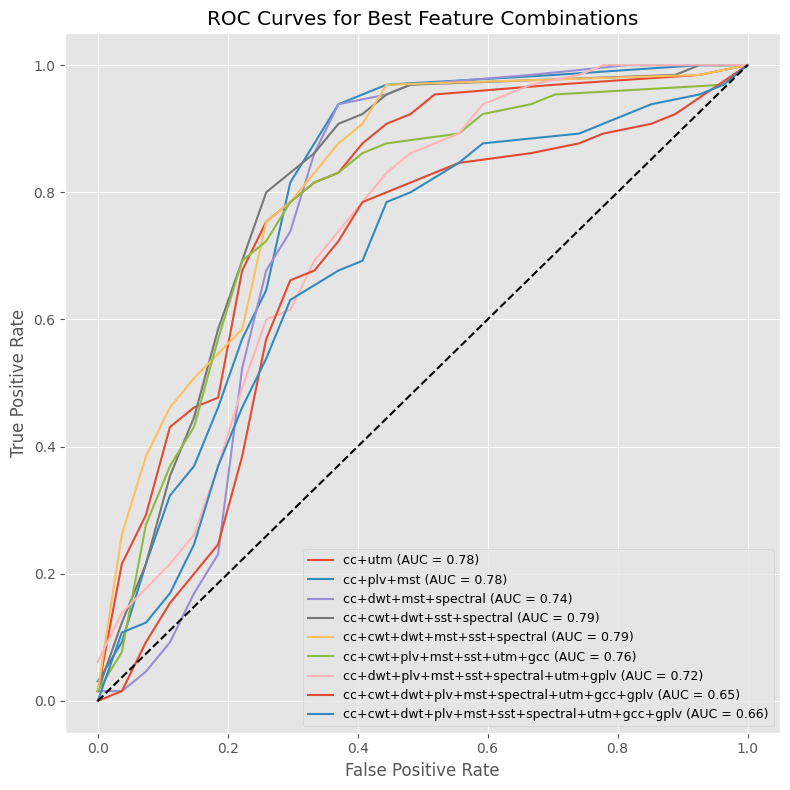

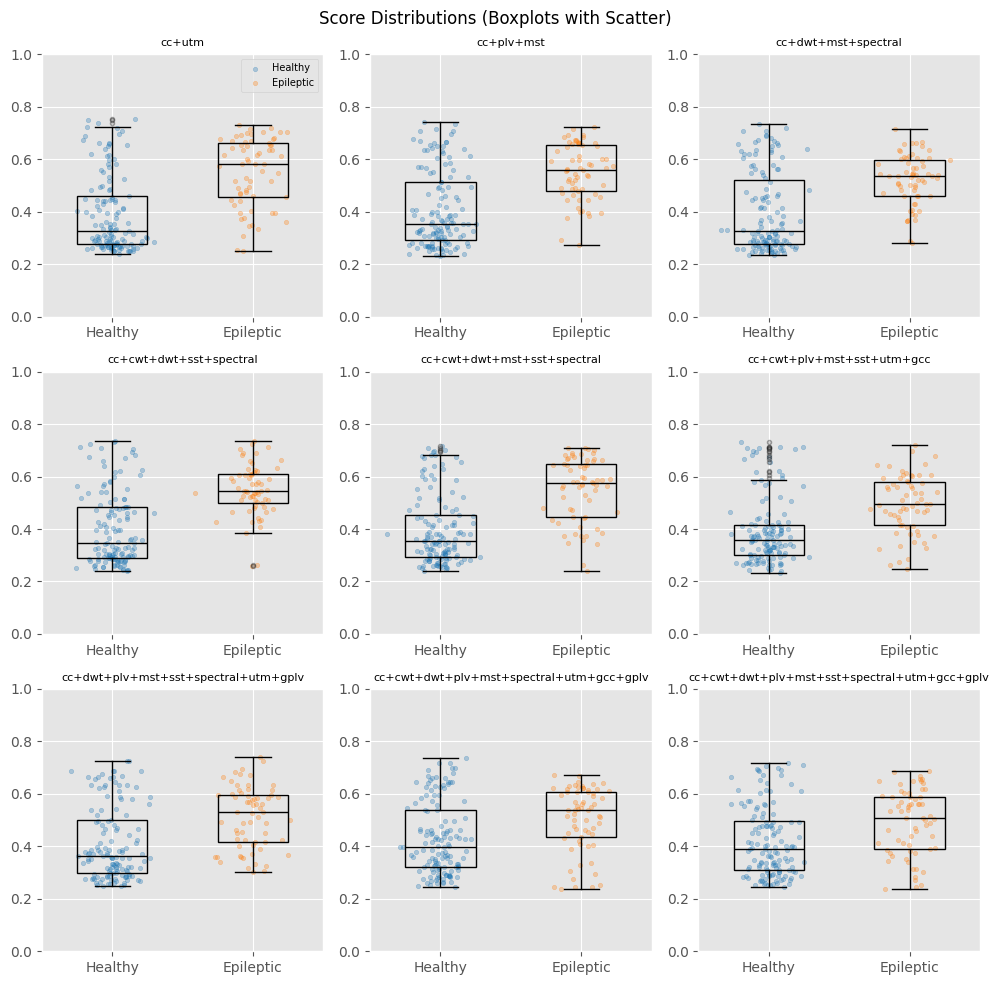

NameError: name 'Patch' is not defined

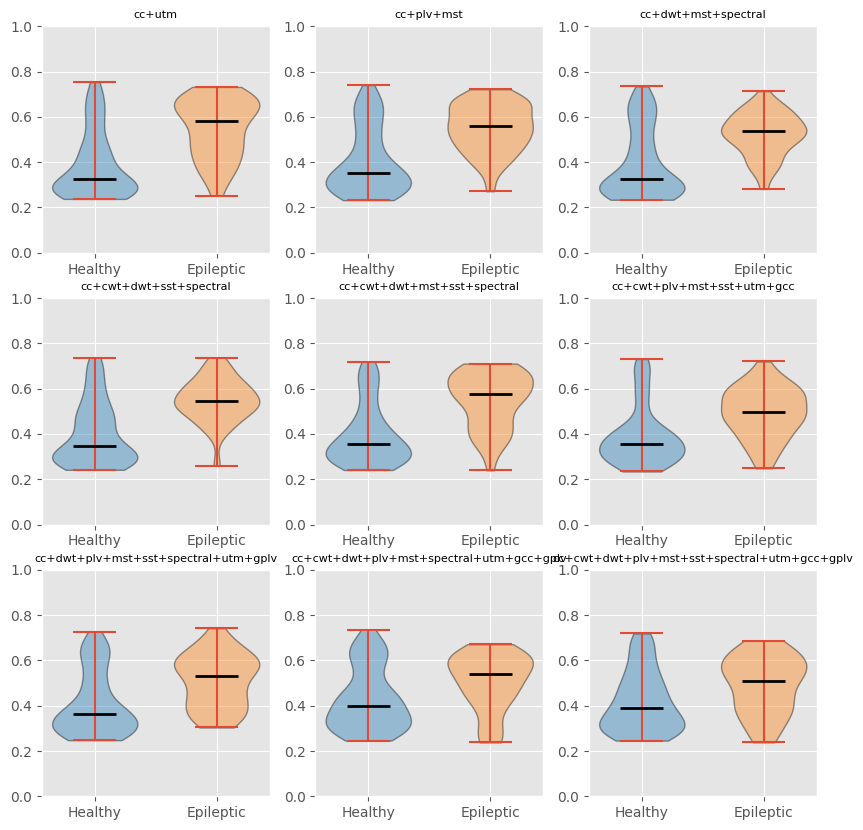

In [4]:
# Example usage: Analyze TUH ensemble bucket data
datafolder = '/space/gzanardini/tuh/tuh_ensemble_bucket/'
df_summary_tuh, df_best_tuh, std_df_tuh = analyze_ensemble_performance(
    datafolder=datafolder, 
    save_plots=True, 
    plot_prefix="tuh_ensemble"
)

In [ ]:
# Example usage: Analyze EMC ensemble bucket data
datafolder = '/space/gzanardini/emc/emc_ensemble_bucket/'
df_summary_emc, df_best_emc, std_df_emc = analyze_ensemble_performance(
    datafolder=datafolder, 
    save_plots=True, 
    plot_prefix="emc_ensemble"
)

  length                                   combination  accuracy       bac  \
0      2                                        cc+utm     0.680  0.651282   
1      3                                    cc+plv+mst     0.695  0.682336   
2      4                           cc+dwt+mst+spectral     0.705  0.689744   
3      5                       cc+cwt+dwt+sst+spectral     0.750  0.754986   
4      6                   cc+cwt+dwt+mst+sst+spectral     0.735  0.731909   
5      7                    cc+cwt+plv+mst+sst+utm+gcc     0.710  0.669516   
6      8          cc+dwt+plv+mst+sst+spectral+utm+gplv     0.685  0.650997   
7      9      cc+cwt+dwt+plv+mst+spectral+utm+gcc+gplv     0.675  0.647578   
8     10  cc+cwt+dwt+plv+mst+sst+spectral+utm+gcc+gplv     0.665  0.640171   

      bac80  f1_score  precision    recall       auc     auprc  
0  0.764387  0.531373   0.506886  0.569231  0.778348  0.548218  
1  0.794587  0.579183   0.525833  0.646154  0.776638  0.521004  
2  0.809972  0.586335   

In [ ]:
# Compare results across datasets (if both were analyzed)
print("\n" + "="*50)
print("COMPARISON ACROSS DATASETS")
print("="*50)

if 'df_best_tuh' in locals() and 'df_best_emc' in locals():
    print("\nTUH Best Combinations:")
    print(df_best_tuh[['combination', 'auc', 'bac80', 'f1_score']].round(3))
    
    print("\nEMC Best Combinations:")  
    print(df_best_emc[['combination', 'auc', 'bac80', 'f1_score']].round(3))
    
    # Find common best combinations
    common_combinations = set(df_best_tuh['combination']) & set(df_best_emc['combination'])
    if common_combinations:
        print(f"\nCommon best combinations: {common_combinations}")
    else:
        print("\nNo common best combinations between datasets.")
else:
    print("Run analysis on both datasets to compare results.")

                                    combination  accuracy       bac     bac80  \
0                                        cc+utm  0.075829  0.095220  0.083303   
1                                    cc+plv+mst  0.020917  0.020814  0.042370   
2                           cc+dwt+mst+spectral  0.041079  0.051592  0.062748   
3                       cc+cwt+dwt+sst+spectral  0.075000  0.075780  0.039789   
4                   cc+cwt+dwt+mst+sst+spectral  0.114018  0.101352  0.067949   
5                    cc+cwt+plv+mst+sst+utm+gcc  0.028504  0.056254  0.074765   
6          cc+dwt+plv+mst+sst+spectral+utm+gplv  0.037914  0.069283  0.047470   
7      cc+cwt+dwt+plv+mst+spectral+utm+gcc+gplv  0.072887  0.113544  0.076802   
8  cc+cwt+dwt+plv+mst+sst+spectral+utm+gcc+gplv  0.084039  0.106508  0.093530   

   f1_score  precision    recall       auc     auprc        AP  length  
0  0.122127   0.109580  0.177090  0.065011  0.046519  0.040821       2  
1  0.025491   0.026418  0.042133  0.048875 

## Summary and Next Steps

- The `analyze_ensemble_performance()` function provides a complete analysis pipeline for ensemble performance evaluation.
- It takes a data folder path as input and generates all metrics, tables, and visualizations.
- The function returns summary dataframes for further analysis if needed.
- Use different paths from the `available_paths` list to analyze different datasets.

**Function features:**
- Computes all relevant metrics (AUC, BAC, BAC80, F1, precision, recall, AUPRC, AP)
- Finds best combinations per feature length using composite metric (AUC + BAC80)
- Generates ROC curves, boxplots, and violin plots for visualization
- Saves plots as PDF files with customizable prefixes
- Returns dataframes for further analysis

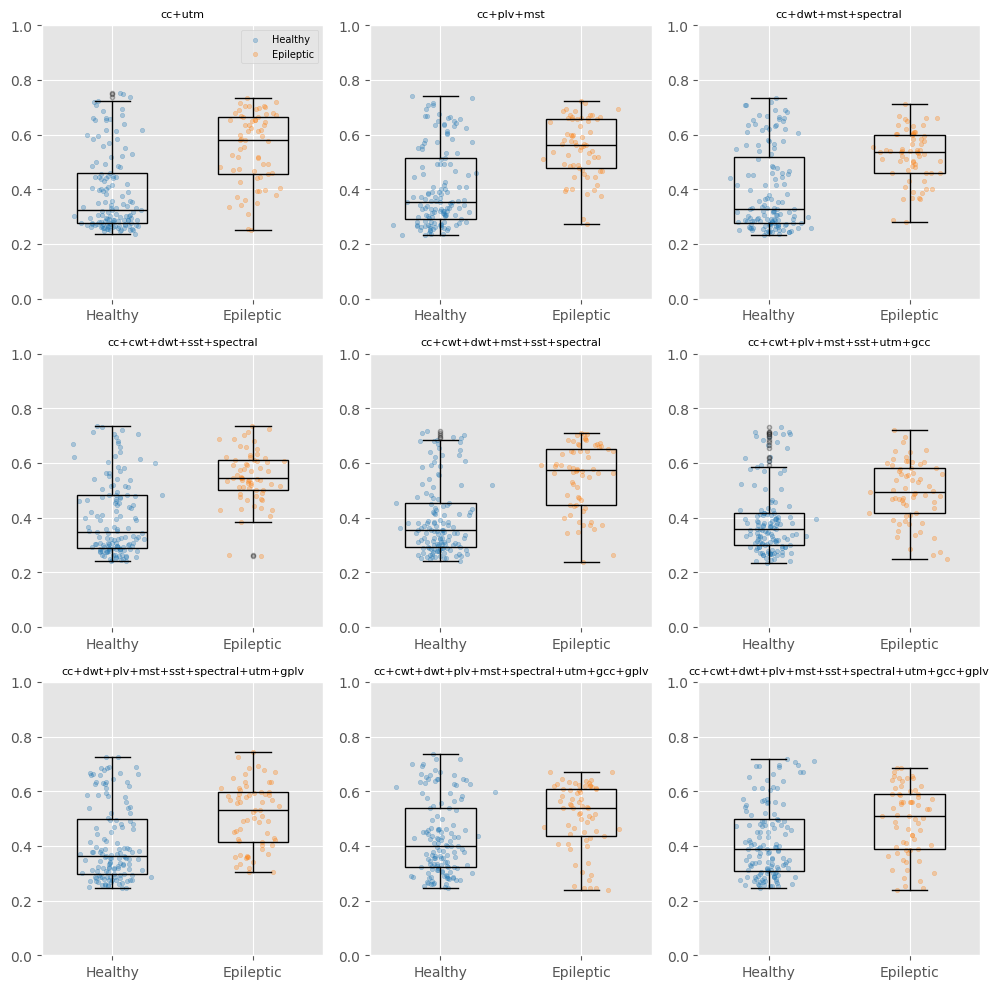

In [ ]:
# for each of the combinations in df_best, plot a boxplot for the scores of the predictions per each class, 
fig, ax = plt.subplots(3, 3, figsize=(10, 10))

for idx, row in df_best.iterrows():
    comb = row['combination']
    comb_files = [file for file in files if file.startswith(comb + '_') and 'predictions' in file]

    # Collect all scores for each class
    scores_class_0 = []
    scores_class_1 = []

    for file in comb_files:
        df_file = pd.read_csv(datafolder + file)
        scores_class_0.extend(df_file.loc[df_file['y_true'] == 0, 'y_prob'].values)
        scores_class_1.extend(df_file.loc[df_file['y_true'] == 1, 'y_prob'].values)

    data = [scores_class_0, scores_class_1]

    # plot a boxplot with empty boxes (no fill)
    ax_idx = divmod(idx, 3)
    ax[ax_idx].boxplot(
        data, positions=[0, 1], widths=0.5, patch_artist=True,
        boxprops=dict(facecolor='none', edgecolor='black'),
        medianprops=dict(color='black'),
        whiskerprops=dict(color='black'),
        capprops=dict(color='black'),
        flierprops=dict(markerfacecolor='gray', marker='o', markersize=3, linestyle='none', alpha=0.3)
    )

    # plot the scatter plot behind the boxplot
    jitter = 0.1
    x0 = np.random.normal(0, jitter, size=len(scores_class_0))
    x1 = np.random.normal(1, jitter, size=len(scores_class_1))
    ax[ax_idx].scatter(x0, scores_class_0, alpha=0.3, color='tab:blue', s=10, label='Healthy' if idx == 0 else "")
    ax[ax_idx].scatter(x1, scores_class_1, alpha=0.3, color='tab:orange', s=10, label='Epileptic' if idx == 0 else "")

    ax[ax_idx].set_xticks([0, 1])
    ax[ax_idx].set_xticklabels(['Healthy', 'Epileptic'])
    ax[ax_idx].set_title(comb, fontsize=8)
    ax[ax_idx].set_ylim(0, 1)

# Add legend to the first subplot only
ax[0, 0].legend(loc='upper right', fontsize=7)
plt.tight_layout()
plt.show()


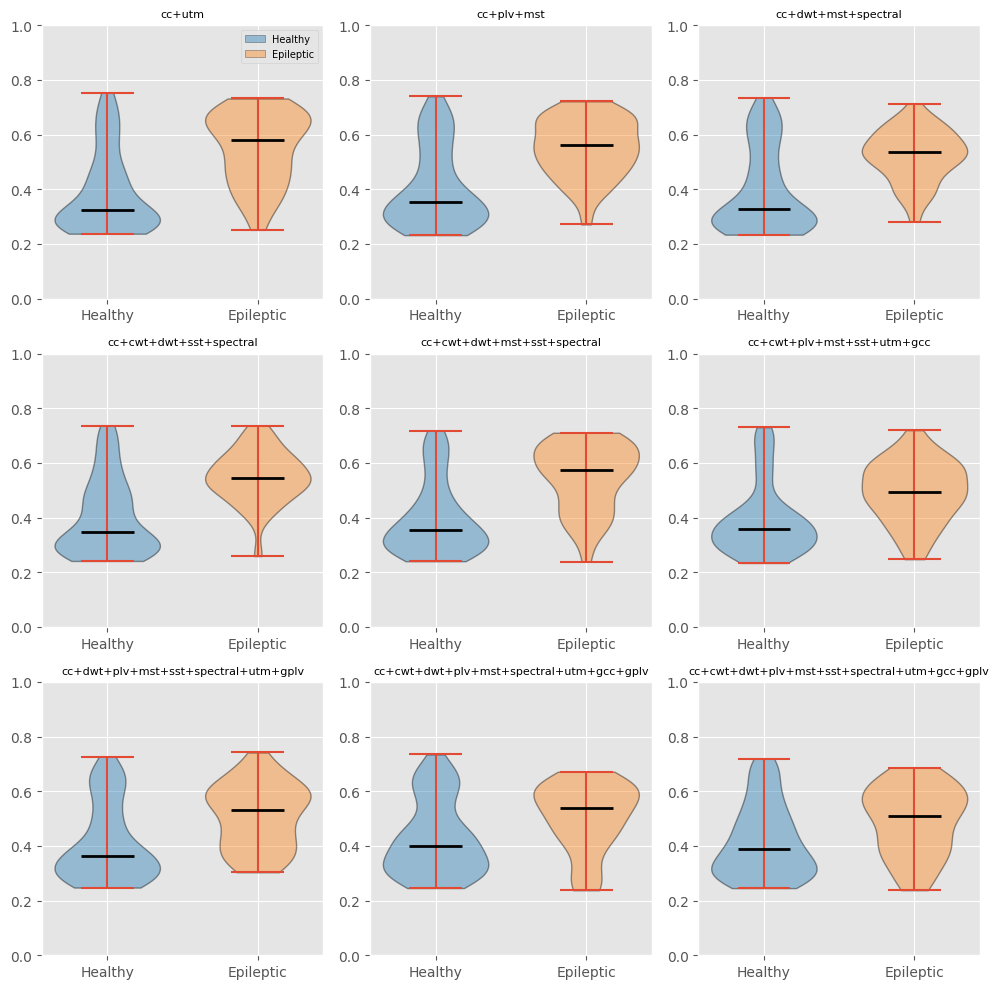

In [ ]:
# For each of the combinations in df_best, plot a violinplot for the scores of the predictions per each class
fig, ax = plt.subplots(3, 3, figsize=(10, 10))

for idx, row in df_best.iterrows():
    comb = row['combination']
    comb_files = [file for file in files if file.startswith(comb + '_') and 'predictions' in file]

    # Collect all scores for each class
    scores_class_0 = []
    scores_class_1 = []

    for file in comb_files:
        df_file = pd.read_csv(datafolder + file)
        scores_class_0.extend(df_file.loc[df_file['y_true'] == 0, 'y_prob'].values)
        scores_class_1.extend(df_file.loc[df_file['y_true'] == 1, 'y_prob'].values)

    data = [scores_class_0, scores_class_1]

    ax_idx = divmod(idx, 3)
    # Violinplot for both classes
    parts = ax[ax_idx].violinplot(data, positions=[0, 1], widths=0.7, showmeans=False, showmedians=True, showextrema=True)
    # Set colors for violins
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(['tab:blue', 'tab:orange'][i])
        pc.set_alpha(0.4)
        pc.set_edgecolor('black')
        pc.set_linewidth(1)
    if 'cmedians' in parts:
        parts['cmedians'].set_color('black')
        parts['cmedians'].set_linewidth(2)

    ax[ax_idx].set_xticks([0, 1])
    ax[ax_idx].set_xticklabels(['Healthy', 'Epileptic'])
    ax[ax_idx].set_title(comb, fontsize=8)
    ax[ax_idx].set_ylim(0, 1)

# Add legend to the first subplot only
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='tab:blue', edgecolor='black', label='Healthy', alpha=0.4),
                   Patch(facecolor='tab:orange', edgecolor='black', label='Epileptic', alpha=0.4)]
ax[0, 0].legend(handles=legend_elements, loc='upper right', fontsize=7)
plt.tight_layout()
plt.show()